<a href="https://colab.research.google.com/github/svb8716/CustomerChurn/blob/main/DSA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/customer_churn.csv')

In [ ]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505204,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505205,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505206,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505207,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505209 entries, 0 to 505208
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505208 non-null  float64
 1   Age                505205 non-null  float64
 2   Gender             505202 non-null  object 
 3   Tenure             505203 non-null  float64
 4   Usage Frequency    505203 non-null  float64
 5   Support Calls      505201 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505204 non-null  object 
 8   Contract Length    505201 non-null  object 
 9   Total Spend        505203 non-null  float64
 10  Last Interaction   505204 non-null  float64
 11  Churn              505207 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB


In [ ]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505208.000000,505205.000000,505203.000000,505203.000000,505201.000000,505206.000000,505203.000000,505204.000000,505207.000000
mean,200778.686038,39.704267,31.350542,15.714762,3.833284,13.496809,620.070057,14.610547,0.555202
std,137241.611821,12.670587,17.237500,8.619301,3.133591,8.451197,245.320016,8.608254,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63826.750000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193038.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.250000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


# Data Cleaning

In [ ]:
df = df.drop('CustomerID', axis = 1)
df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
505204,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505205,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505206,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505207,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [ ]:
df[df.isnull().any(axis = 1)].head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
32021,28.0,NaN,57.0,28.0,4.0,2.0,Basic,Annual,184.0,18.0,1.0
91210,63.0,Male,47.0,16.0,3.0,NaN,Basic,Monthly,301.0,1.0,1.0
91248,19.0,Male,NaN,23.0,8.0,3.0,Basic,Monthly,857.0,16.0,NaN
91314,55.0,Female,33.0,20.0,8.0,1.0,NaN,Monthly,NaN,24.0,1.0
91320,32.0,Female,59.0,29.0,10.0,17.0,Basic,NaN,795.0,29.0,1.0


In [ ]:
df.isnull().sum()

,0
Age,4
Gender,7
Tenure,6
Usage Frequency,6
Support Calls,8
Payment Delay,3
Subscription Type,5
Contract Length,8
Total Spend,6
Last Interaction,5


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].mean())

In [ ]:
df['Usage Frequency'] = df['Usage Frequency'].fillna(df['Usage Frequency'].mean())

In [ ]:
df['Support Calls'] = df['Support Calls'].fillna(df['Support Calls'].mean())

In [ ]:
df['Payment Delay'] = df['Payment Delay'].fillna(df['Payment Delay'].mean())

In [ ]:
df['Total Spend'] = df['Total Spend'].fillna(df['Total Spend'].mean())

In [ ]:
df['Last Interaction'] = df['Last Interaction'].fillna(df['Last Interaction'].mean())

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,7
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,5
Contract Length,8
Total Spend,0
Last Interaction,0


In [ ]:
df['Subscription Type'] = df['Subscription Type'].fillna(df['Subscription Type'].mode()[0])

In [ ]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [ ]:
df['Contract Length'] = df['Contract Length'].fillna(df['Contract Length'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0
Last Interaction,0


In [ ]:
df[df.duplicated()].shape

(2, 11)

In [ ]:
df[df.duplicated()]

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
103,60.0,Male,50.0,10.0,2.0,4.0,Standard,Quarterly,552.0,8.0,1.0
455422,22.0,Female,37.0,10.0,2.0,7.0,Basic,Quarterly,111.0,11.0,0.0


In [ ]:
df = df.drop_duplicates()
df[df.duplicated()].shape

(0, 11)

In [ ]:
df[df['Churn'].isna()]

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
91248,19.000000,Male,31.350542,23.000000,8.000000,3.000000,Basic,Monthly,857.000000,16.000000,NaN
199296,39.704267,Male,31.350542,15.714762,3.833284,13.496809,Standard,Annual,620.070057,14.610547,NaN


In [ ]:
df = df.dropna(subset=['Churn'])

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0
Last Interaction,0


# EDA

In [ ]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [ ]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505205.000000,505205.000000,505205.00000,505205.000000,505205.000000,505205.00000,505205.000000,505205.000000
mean,39.704302,31.350494,15.71477,3.833283,13.496862,620.07073,14.610565,0.555202
std,12.670497,17.237444,8.61927,3.133571,8.451177,245.31824,8.608239,0.496944
min,18.000000,1.000000,1.00000,0.000000,0.000000,100.00000,1.000000,0.000000
25%,29.000000,16.000000,8.00000,1.000000,6.000000,446.00000,7.000000,0.000000
50%,40.000000,32.000000,16.00000,3.000000,13.000000,648.88000,14.000000,1.000000
75%,49.000000,46.000000,23.00000,6.000000,20.000000,824.00000,22.000000,1.000000
max,65.000000,60.000000,30.00000,10.000000,30.000000,1000.00000,30.000000,1.000000


### Pairplot

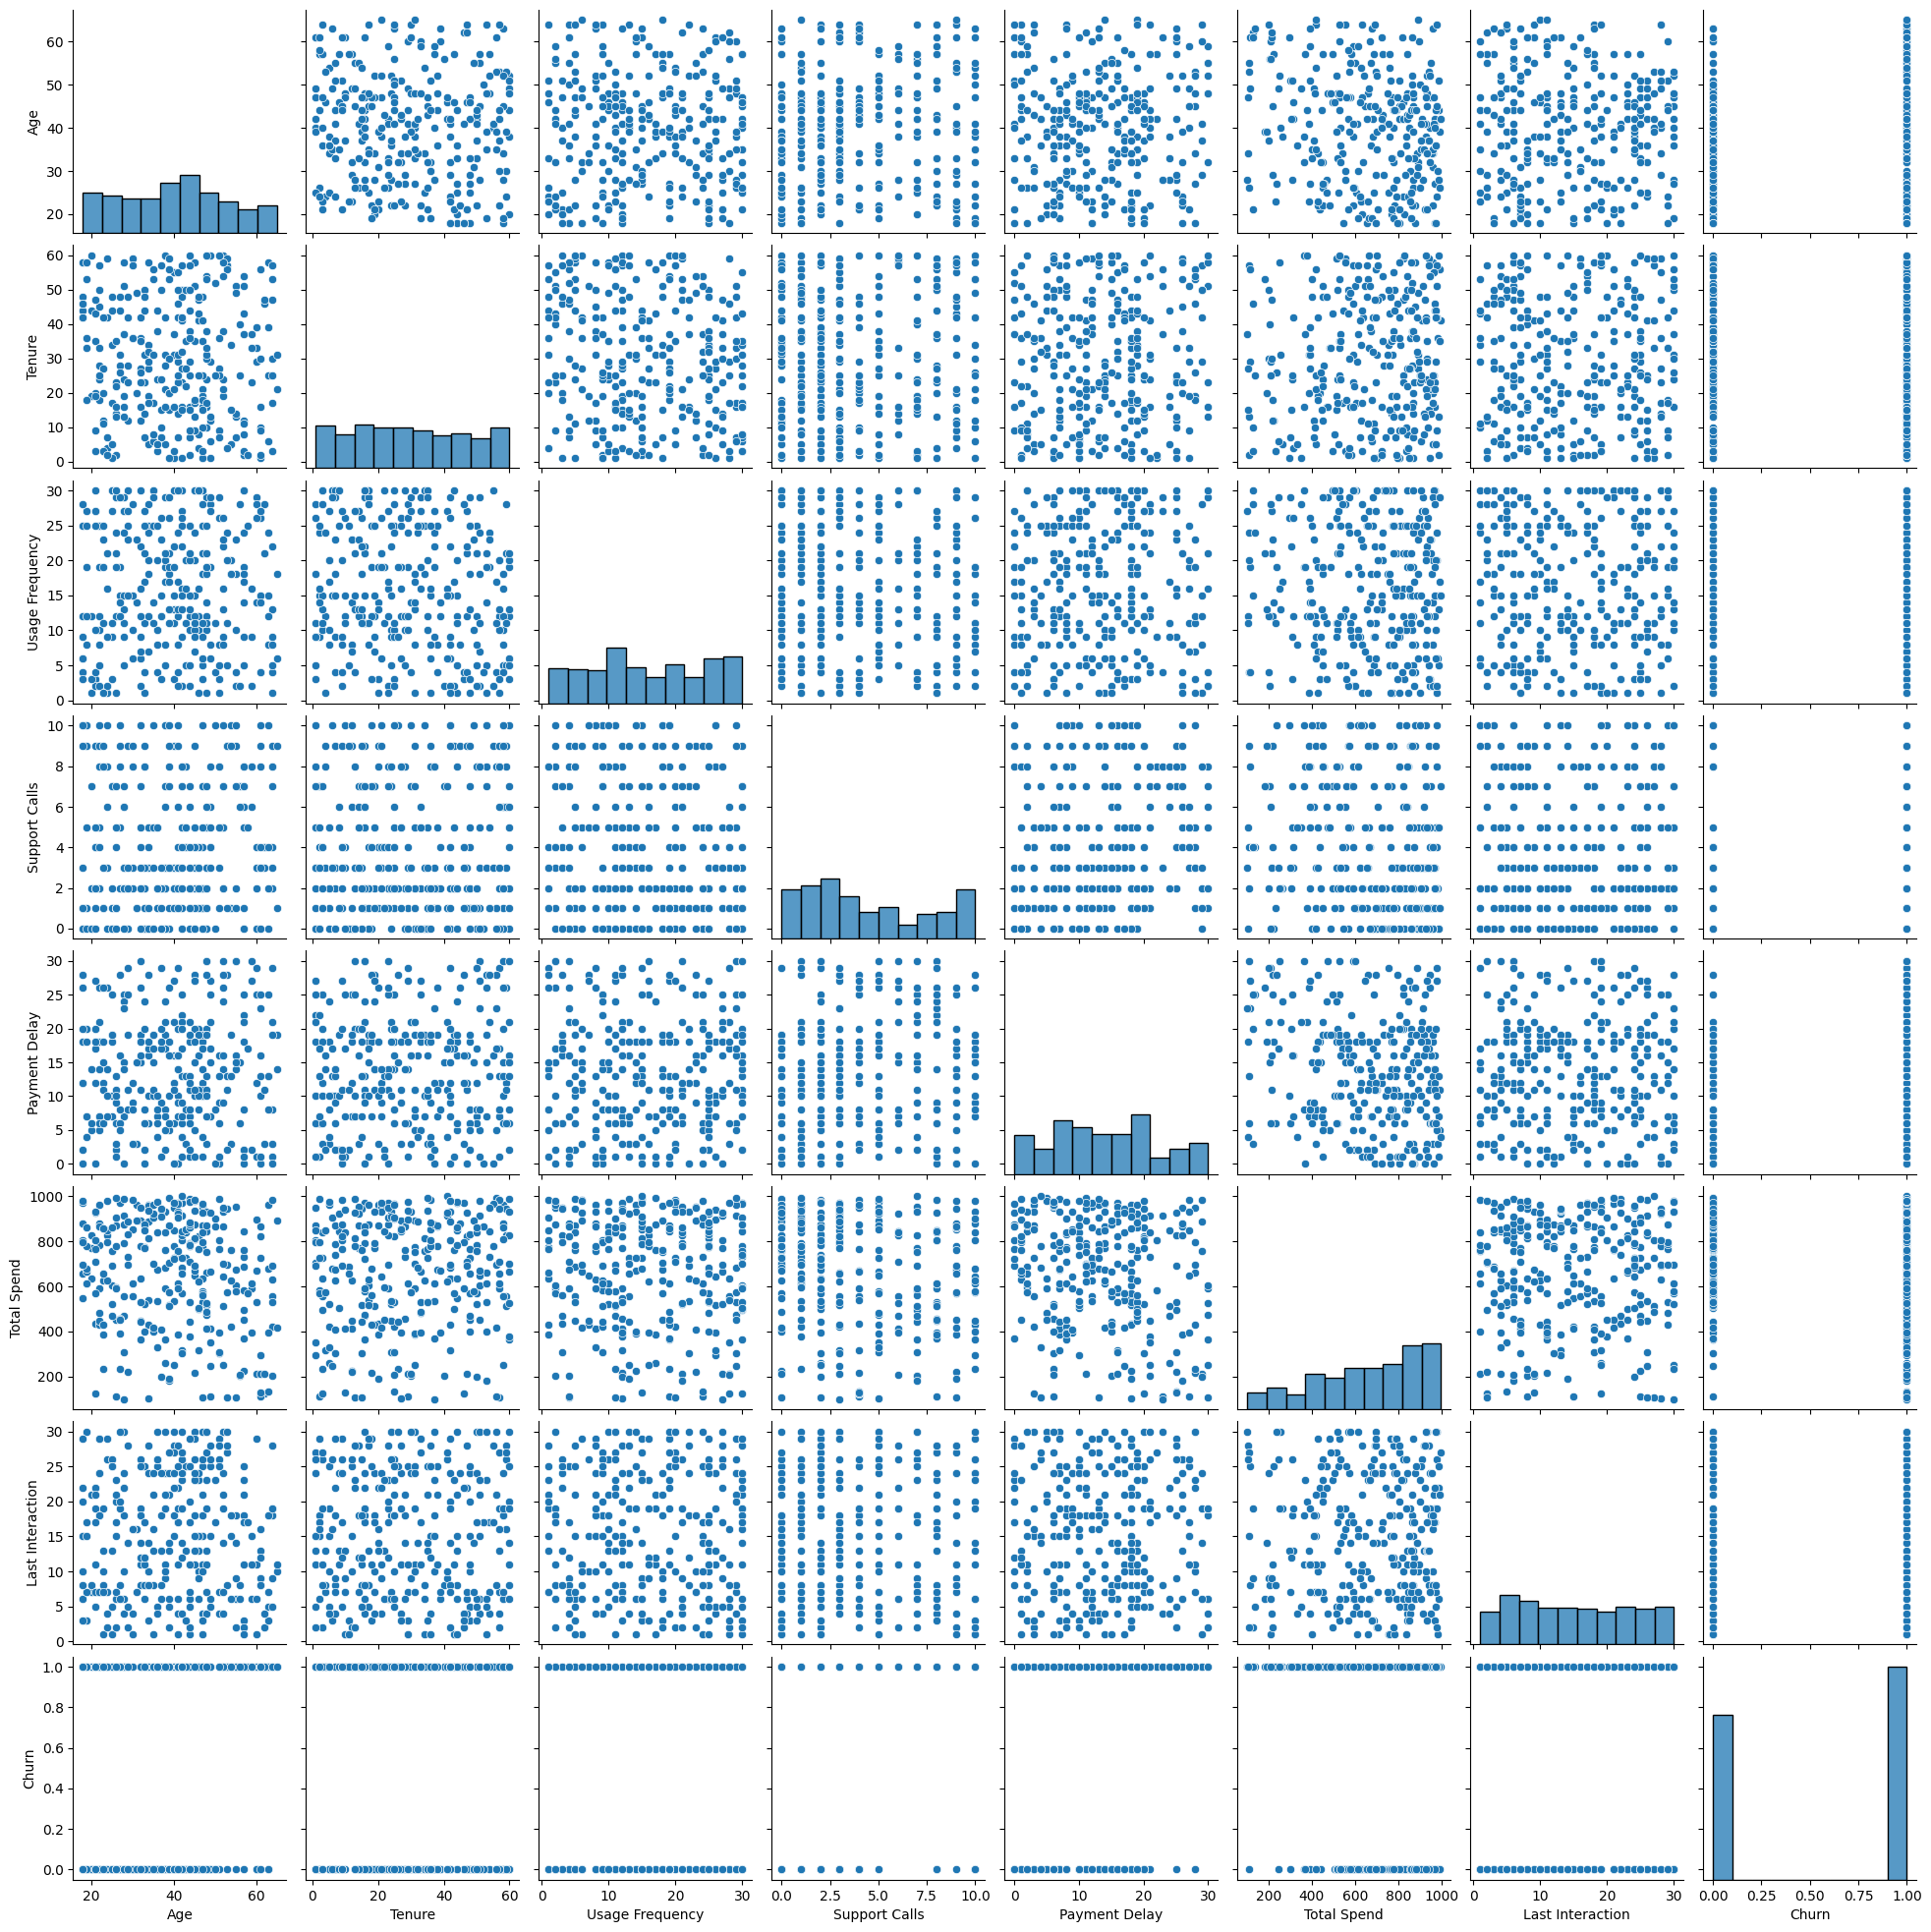

In [ ]:
# sampling data to 300 samples
df_sampled = df.sample(n=300, random_state=42)
sns.pairplot(df_sampled)

### Histogram

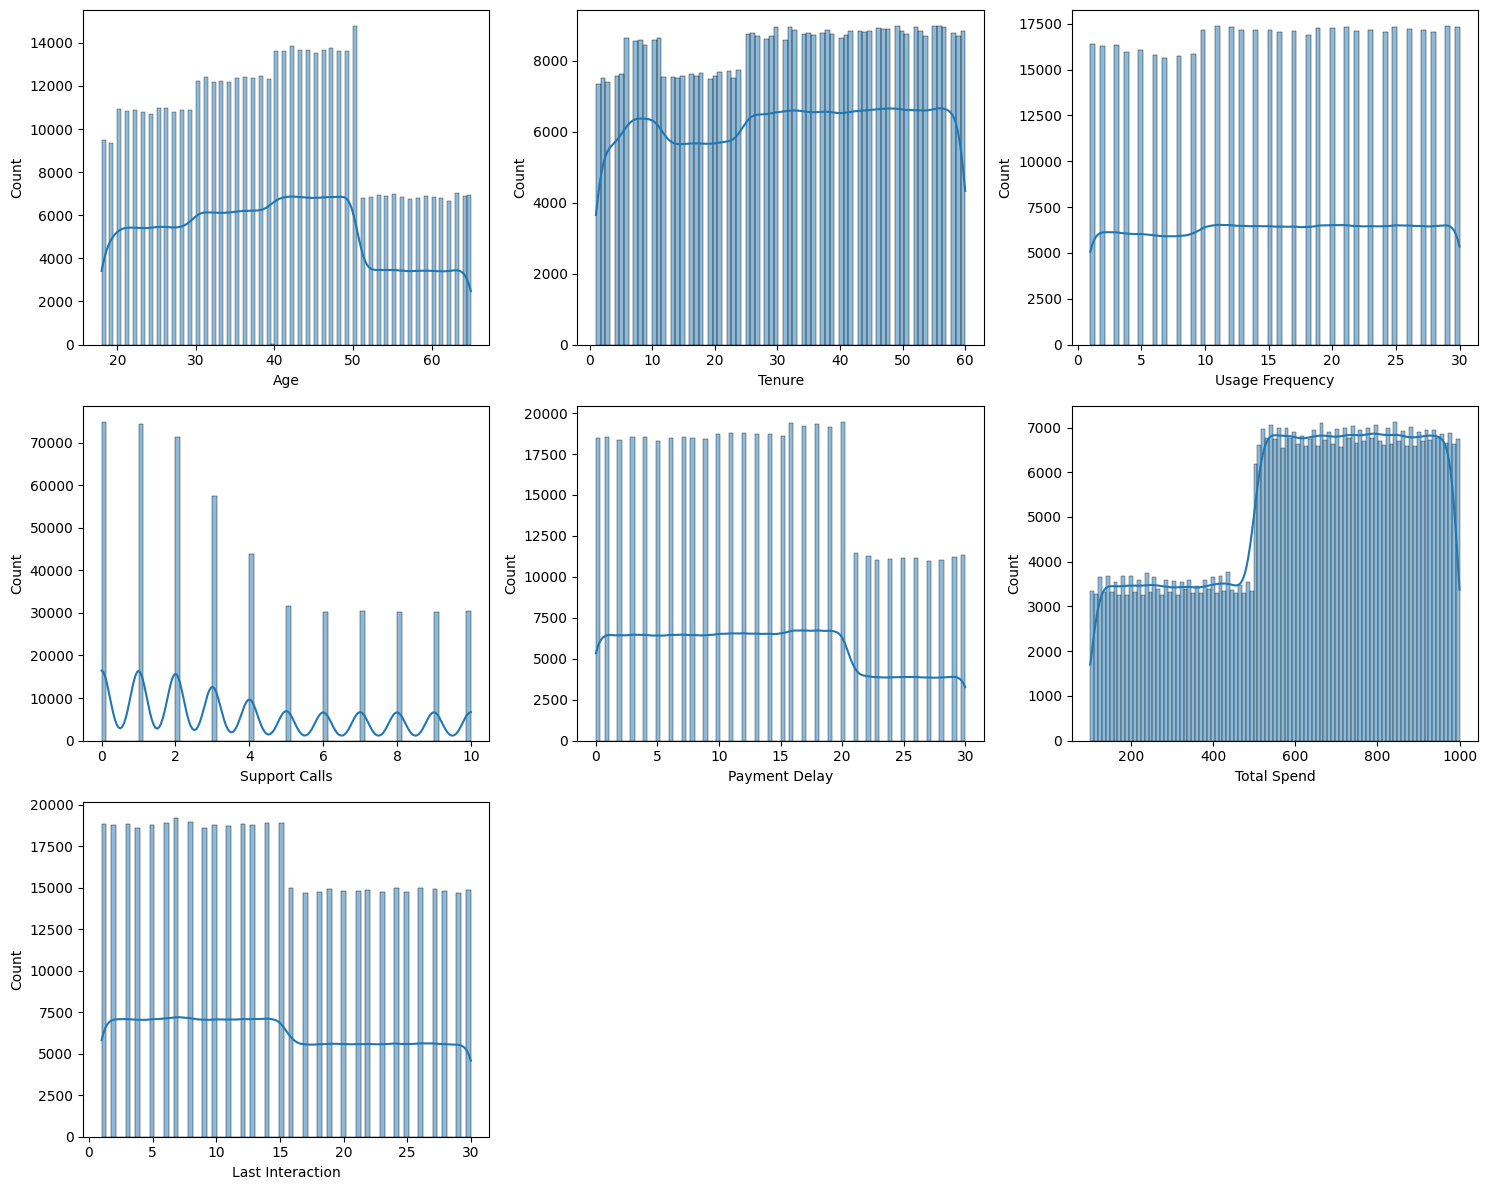

In [ ]:
numeric_cols = [col for col in df.select_dtypes(include='number').columns if col != 'Churn']
fig, axes = plt.subplots(nrows=-(-len(numeric_cols)//3), ncols=3, figsize=(15, 4 * -(-len(numeric_cols)//3)))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], ax=ax, kde=True)
for ax in axes.flatten()[len(numeric_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Pieplot

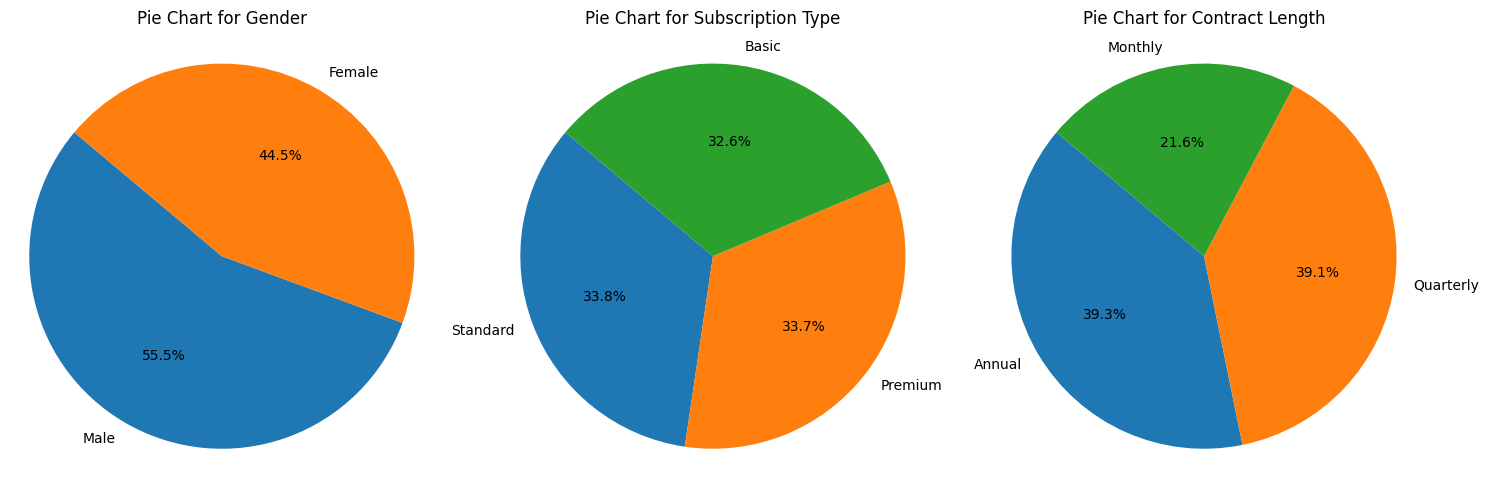

In [ ]:
object_cols = df.select_dtypes(include='object').columns
fig, axes = plt.subplots(nrows=-(-len(object_cols)//3), ncols=3, figsize=(15, 5 * -(-len(object_cols)//3)))
for ax, column in zip(axes.flatten(), object_cols):
    value_counts = df[column].value_counts()
    ax.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=140)
    ax.set_title(f'Pie Chart for {column}')
    ax.axis('equal')
for ax in axes.flatten()[len(object_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Boxplot

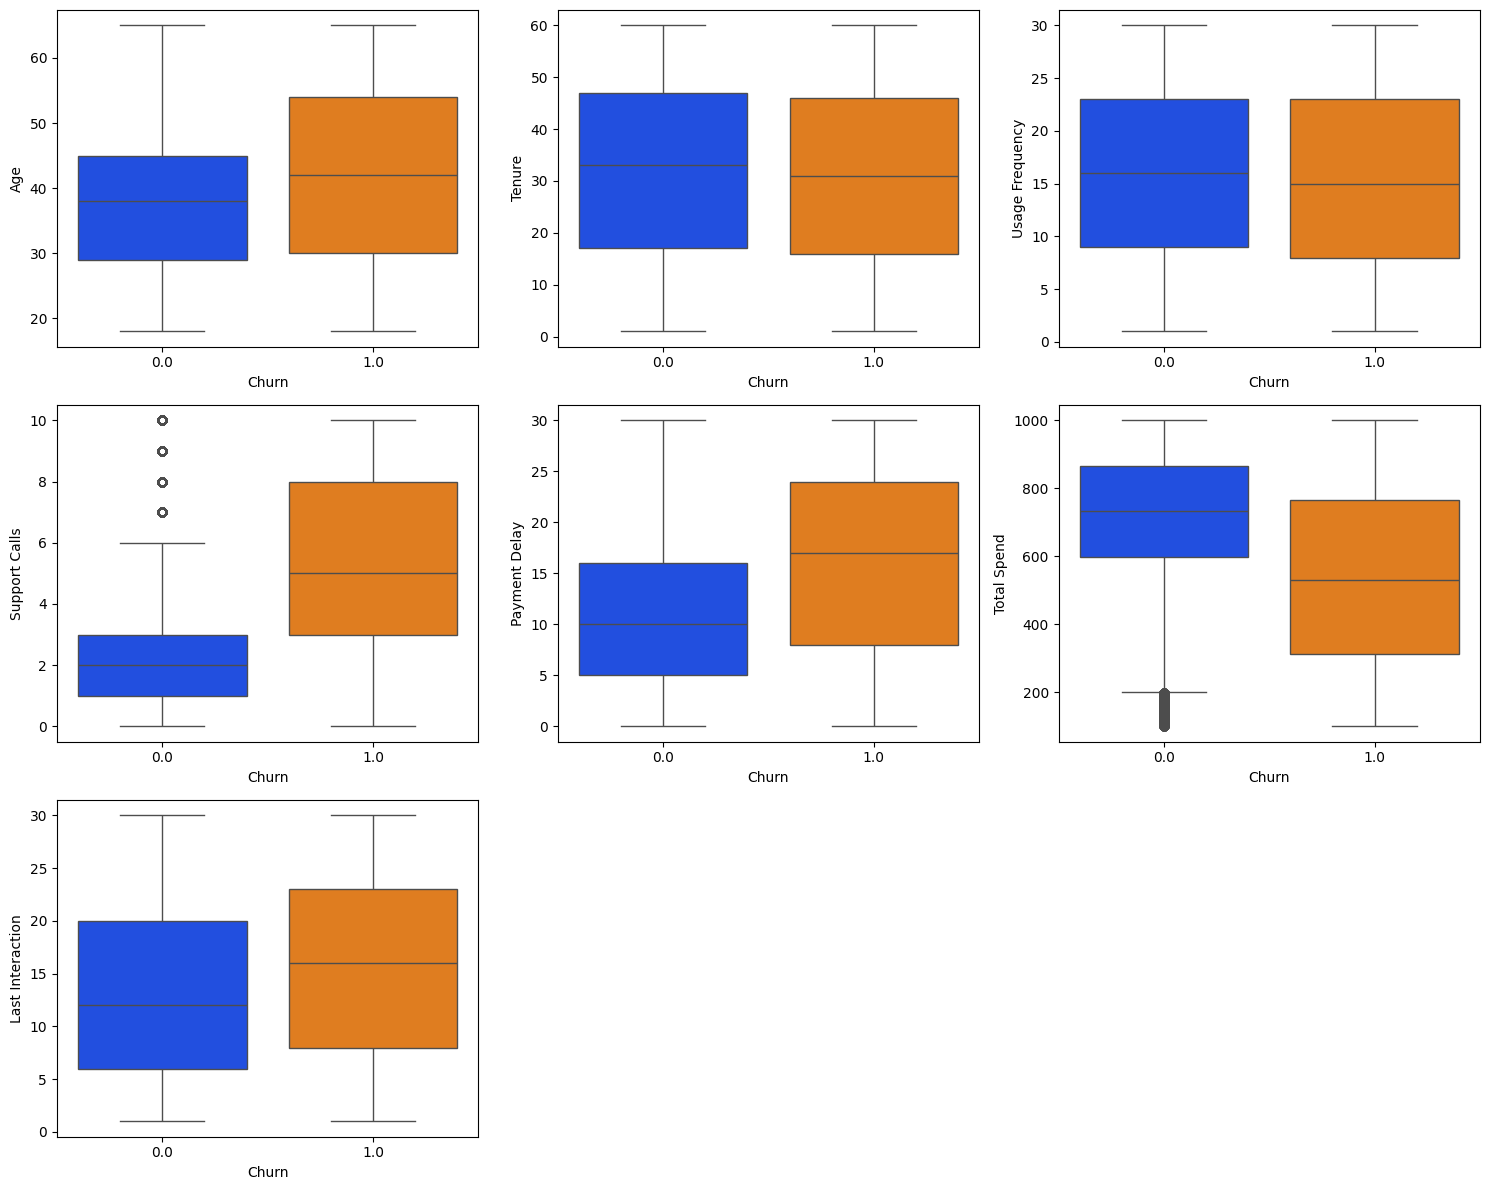

In [ ]:
numeric_cols = [col for col in df.select_dtypes(include='number').columns if col != 'Churn']
fig, axes = plt.subplots(nrows=-(-len(numeric_cols)//3), ncols=3, figsize=(15, 4 * -(-len(numeric_cols)//3)))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(x=df['Churn'], y=df[col], palette='bright', ax=ax)
for ax in axes.flatten()[len(numeric_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Violin Plot

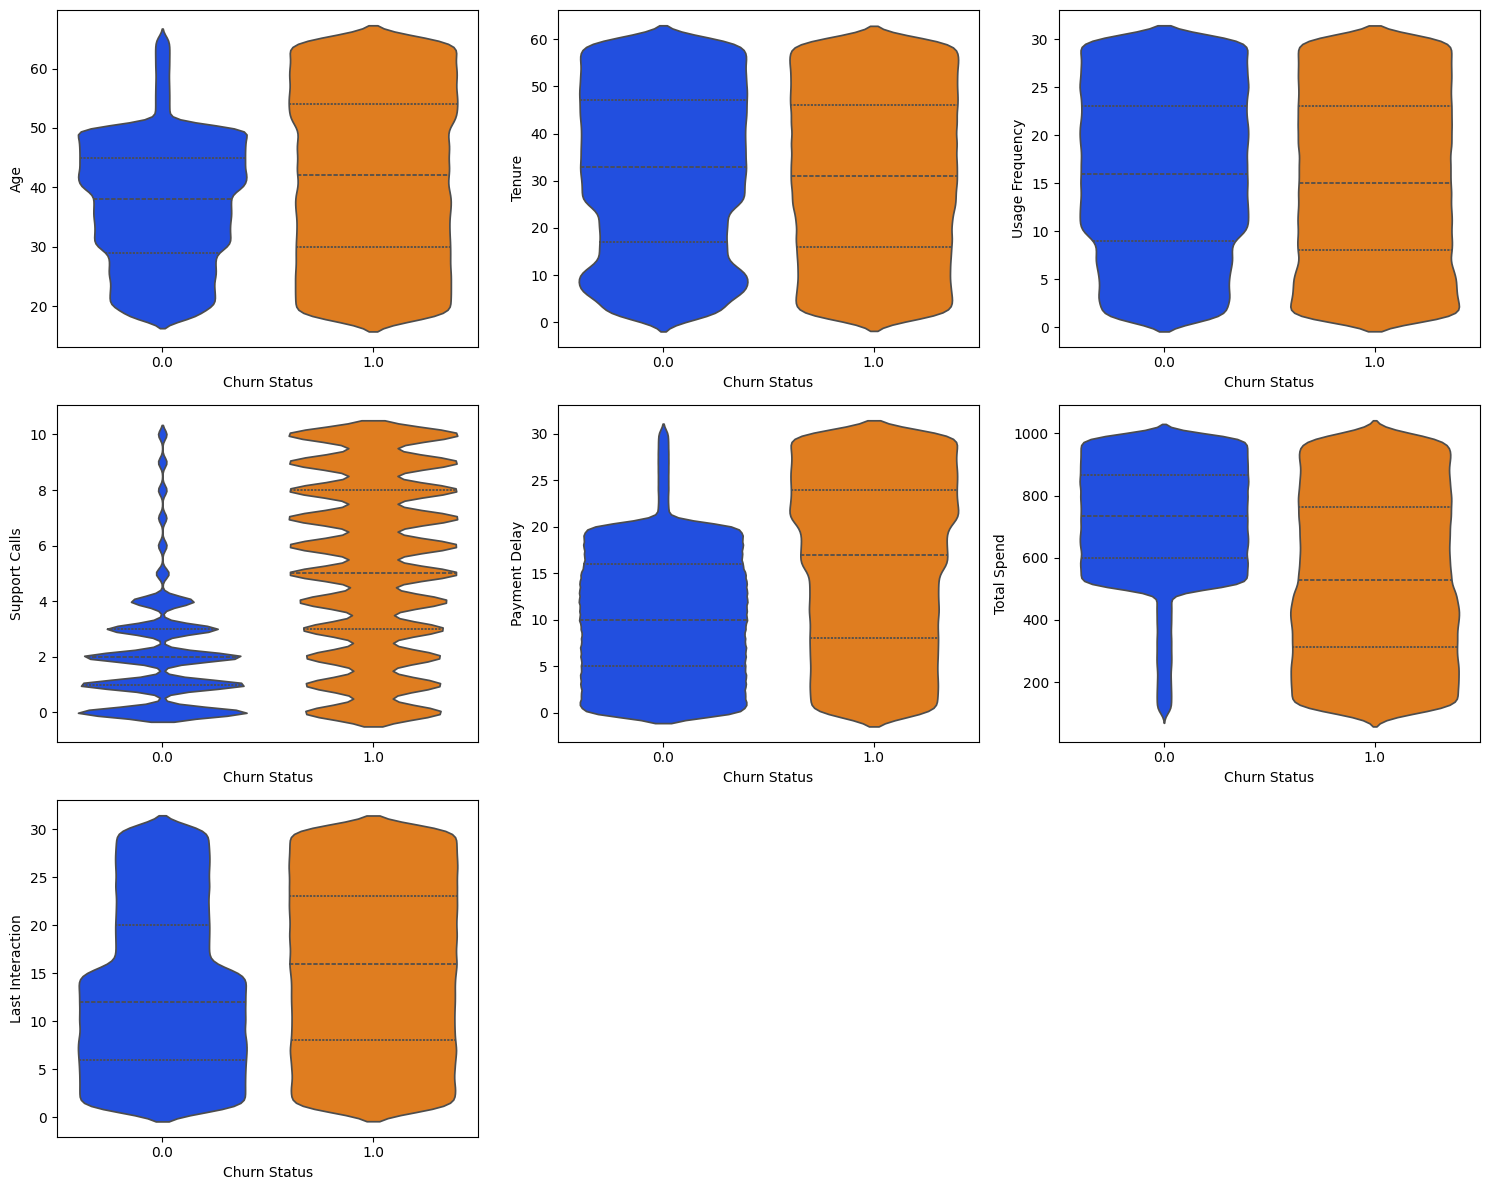

In [ ]:
numeric_cols = [col for col in df.select_dtypes(include='number').columns if col != 'Churn']
fig, axes = plt.subplots(nrows=-(-len(numeric_cols)//3), ncols=3, figsize=(15, 4 * -(-len(numeric_cols)//3)))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.violinplot(x='Churn', y=col, data=df, palette='bright', inner='quartile', ax=ax)
    ax.set_xlabel('Churn Status')
    ax.set_ylabel(col)
for ax in axes[len(numeric_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### KDE Plot

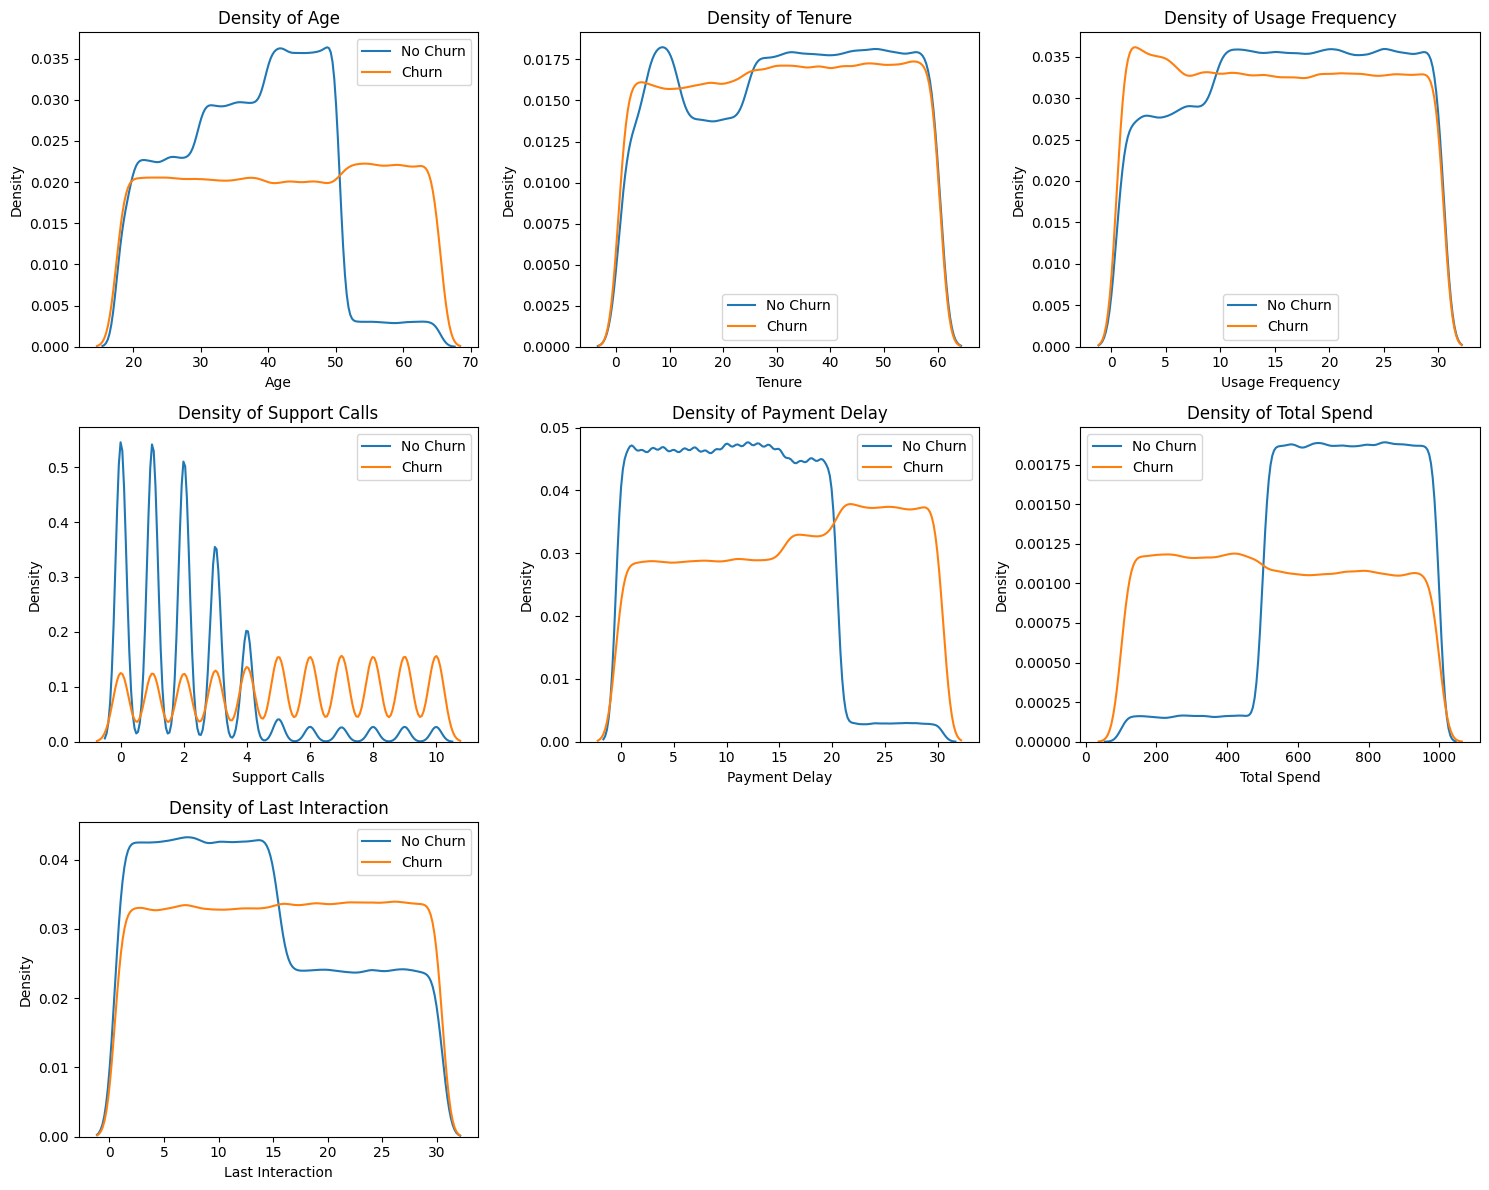

In [ ]:
numeric_cols = [col for col in df.select_dtypes(include=['number']).columns if col != 'Churn']
fig, axes = plt.subplots(nrows=-(-len(numeric_cols)//3), ncols=3, figsize=(15, 4 * -(-len(numeric_cols)//3)))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    sns.kdeplot(data=df[df['Churn'] == 0], x=col, label='No Churn', palette='bright', ax=ax)
    sns.kdeplot(data=df[df['Churn'] == 1], x=col, label='Churn', palette='bright', ax=ax)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.set_title(f'Density of {col}')
    ax.legend()
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

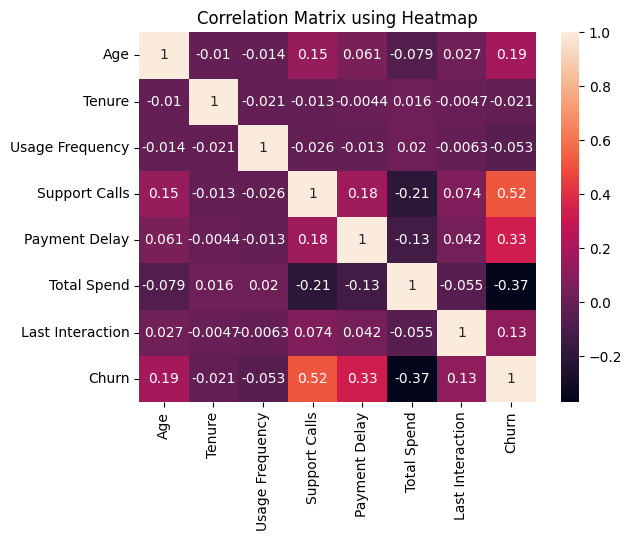

In [ ]:
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix using Heatmap')
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
print("Numeric columns:", numeric_df.columns.tolist())
corr_pairs = corr_matrix.unstack()
filtered_corrs = corr_pairs[(abs(corr_pairs) > 0.3) & (abs(corr_pairs) < 1.0)]
filtered_corrs = filtered_corrs.drop_duplicates()

print(filtered_corrs.sort_values(ascending=False))

Numeric columns: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn']
Support Calls  Churn    0.516286
Payment Delay  Churn    0.329788
Total Spend    Churn   -0.369678
dtype: float64


# Statistical Summary

In [ ]:
from scipy import stats
from scipy.stats import chi2_contingency

def format_p_value(p):
    return f"{p:.4e}" if p < 0.0001 else f"{p:.4f}"

def statistical_summary(df, target='Churn', alpha=0.05):
    if target not in df.columns:
        raise ValueError(f"'{target}' column not found in the DataFrame.")

    results = []

    for col in df.columns:
        if col == target:
            continue

        # Numerical Features
        if pd.api.types.is_numeric_dtype(df[col]):
            groups = [group[col].dropna() for name, group in df.groupby(target)]
            if len(groups) < 2:
                continue  # skip if not enough groups

            if len(groups) == 2:
                # Welch's t-test
                test_type = "T-test"
                stat, p_val = stats.ttest_ind(groups[0], groups[1], equal_var=False)
                diff = groups[1].mean() - groups[0].mean()
            else:
                # ANOVA
                test_type = "ANOVA"
                stat, p_val = stats.f_oneway(*groups)
                diff = None

            results.append({
                "Feature": col,
                "Test": test_type,
                "Group_0_Mean": groups[0].mean(),
                "Group_1_Mean": groups[1].mean() if len(groups) > 1 else None,
                "Difference": diff,
                "p_value": p_val,
                "p_value_formatted": format_p_value(p_val),
                "Significant": p_val < alpha
            })

        # Categorical Features
        elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
            try:
                contingency = pd.crosstab(df[col], df[target])
                if contingency.shape[0] < 2 or contingency.shape[1] < 2:
                    continue
                chi2, p_val, dof, expected = chi2_contingency(contingency)
                results.append({
                    "Feature": col,
                    "Test": "Chi-squared",
                    "Group_0_Mean": None,
                    "Group_1_Mean": None,
                    "Difference": None,
                    "p_value": p_val,
                    "p_value_formatted": format_p_value(p_val),
                    "Significant": p_val < alpha
                })
            except Exception as e:
                print(f"Skipping column {col} due to error: {e}")

    summary_df = pd.DataFrame(results)
    return summary_df.sort_values("p_value")


In [ ]:
summary = statistical_summary(df, target='Churn', alpha=0.05)
print(summary[['Feature', 'Test', 'p_value_formatted', 'Significant']])

             Feature         Test p_value_formatted  Significant
0                Age       T-test        0.0000e+00         True
1             Gender  Chi-squared        0.0000e+00         True
3    Usage Frequency       T-test        0.0000e+00         True
4      Support Calls       T-test        0.0000e+00         True
7    Contract Length  Chi-squared        0.0000e+00         True
5      Payment Delay       T-test        0.0000e+00         True
9   Last Interaction       T-test        0.0000e+00         True
8        Total Spend       T-test        0.0000e+00         True
2             Tenure       T-test        7.0506e-52         True
6  Subscription Type  Chi-squared        3.8827e-41         True


In [ ]:
significant_features = summary[summary['Significant']]['Feature'].tolist()

# Model Building

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
# Features & target
X = df[significant_features]
y = df['Churn']

# Encode categoricals
X = pd.get_dummies(X, drop_first=False)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Optional: Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model1.predict(X_test)
y_proba = model1.predict_proba(X_test)[:,1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
[[38029  6914]
 [ 8517 47581]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.85      0.83     44943
         1.0       0.87      0.85      0.86     56098

    accuracy                           0.85    101041
   macro avg       0.85      0.85      0.85    101041
weighted avg       0.85      0.85      0.85    101041

ROC AUC Score: 0.9082535907266082


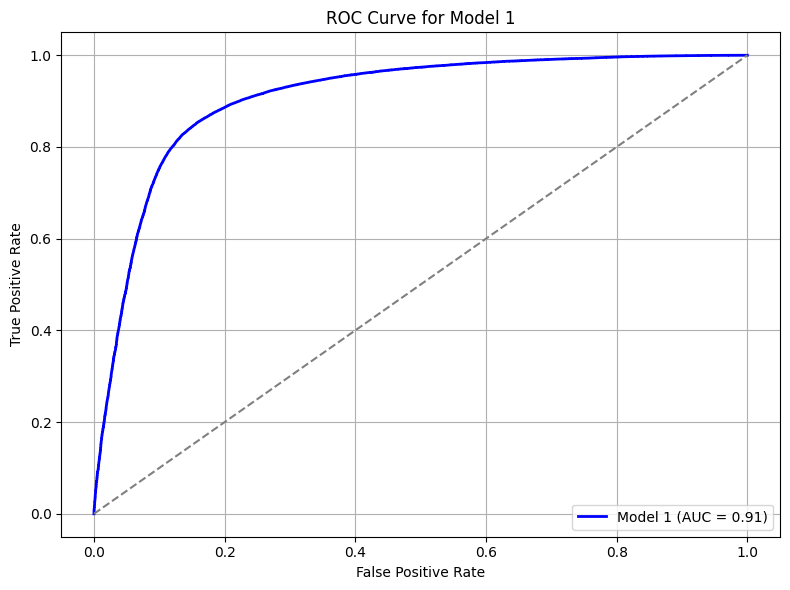

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Model 1 (AUC = {roc_auc:.2f})", color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Model 1')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model2.predict(X_test)
y_proba = model2.predict_proba(X_test)[:,1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
[[38610  6333]
 [  156 55942]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     44943
         1.0       0.90      1.00      0.95     56098

    accuracy                           0.94    101041
   macro avg       0.95      0.93      0.93    101041
weighted avg       0.94      0.94      0.94    101041

ROC AUC Score: 0.9527142586883994


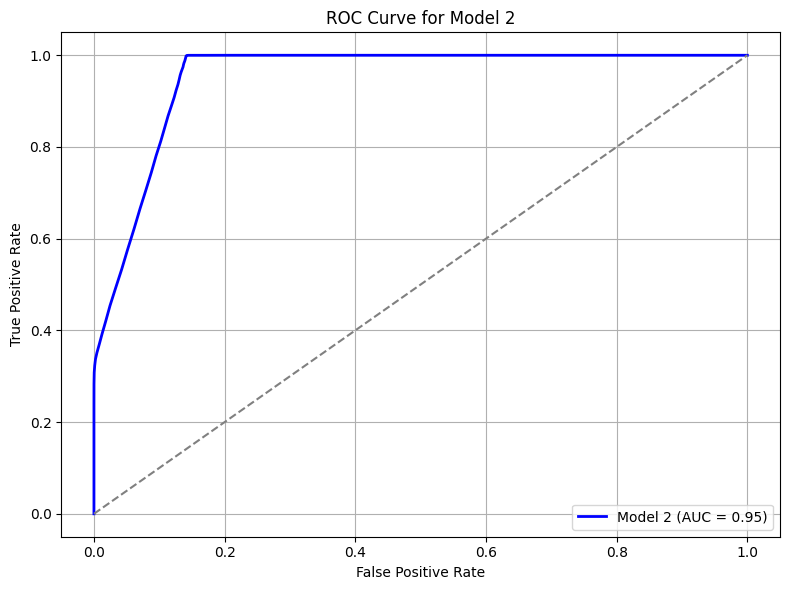

In [ ]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Model 2 (AUC = {roc_auc:.2f})", color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Model 2')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
model3 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model3.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred = model3.predict(X_test)
y_proba = model3.predict_proba(X_test)[:,1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
[[38635  6308]
 [  270 55828]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     44943
         1.0       0.90      1.00      0.94     56098

    accuracy                           0.93    101041
   macro avg       0.95      0.93      0.93    101041
weighted avg       0.94      0.93      0.93    101041

ROC AUC Score: 0.9532526591787598


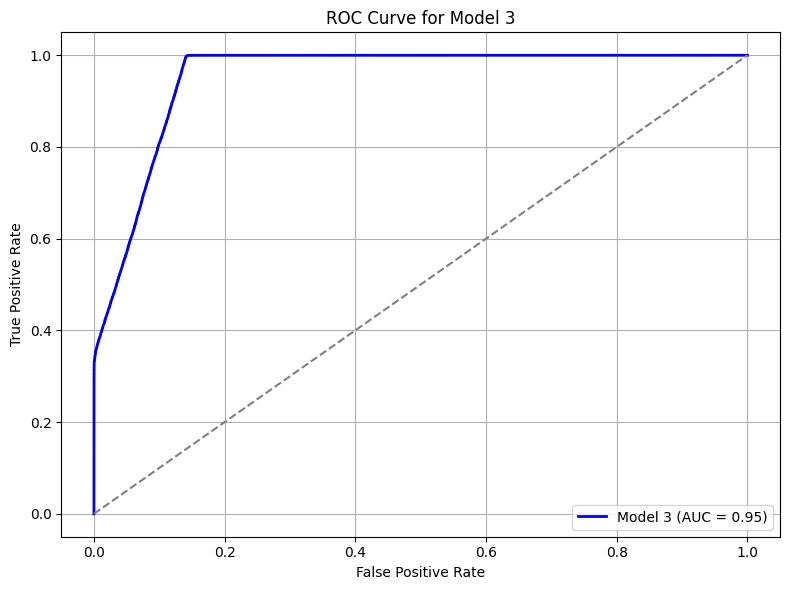

In [ ]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Model 3 (AUC = {roc_auc:.2f})", color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Model 3')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Model 2 was taken into consideration.

# Hyperparameter Tuning using RandomizedSearchCV

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [ ]:
model2 = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(100, 150),
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': randint(2, 6),
    'min_samples_leaf': randint(1, 4),
}

In [ ]:
# Ensure the lengths match
print(len(X_train), len(y_train))

print(X_train.shape)
print(y_train.shape)

404164 404164
(404164, 15)
(404164,)


In [ ]:
X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
    X_train, y_train, test_size=0.98, stratify=y_train, random_state=42
)

# due to low processing strength, using subset of X_train and y_train for hyperparameter tuning

In [ ]:
print(X_train_subset.shape)
print(y_train_subset.shape)

(8083, 15)
(8083,)


In [ ]:
random_search = RandomizedSearchCV(
    estimator=model2,
    param_distributions=param_dist,
    n_iter=10,
    cv=10,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train_subset, y_train_subset)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dc23e1ada90>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dc236fd4d90>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dc239019dd0>},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print("Best Parameters:", random_search.best_params_)
print("Best CV AUC Score:", random_search.best_score_)

best_model = random_search.best_estimator_

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 142}
Best CV AUC Score: 0.9537579805562917


# Evaluate model on Test Data

In [ ]:
best_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 142,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

,0
Support Calls,0.269668
Total Spend,0.197843
Payment Delay,0.139239
Age,0.120087
Contract Length_Monthly,0.099487
Last Interaction,0.055234
Tenure,0.022199
Gender_Male,0.021310
Usage Frequency,0.018671
Contract Length_Annual,0.017413


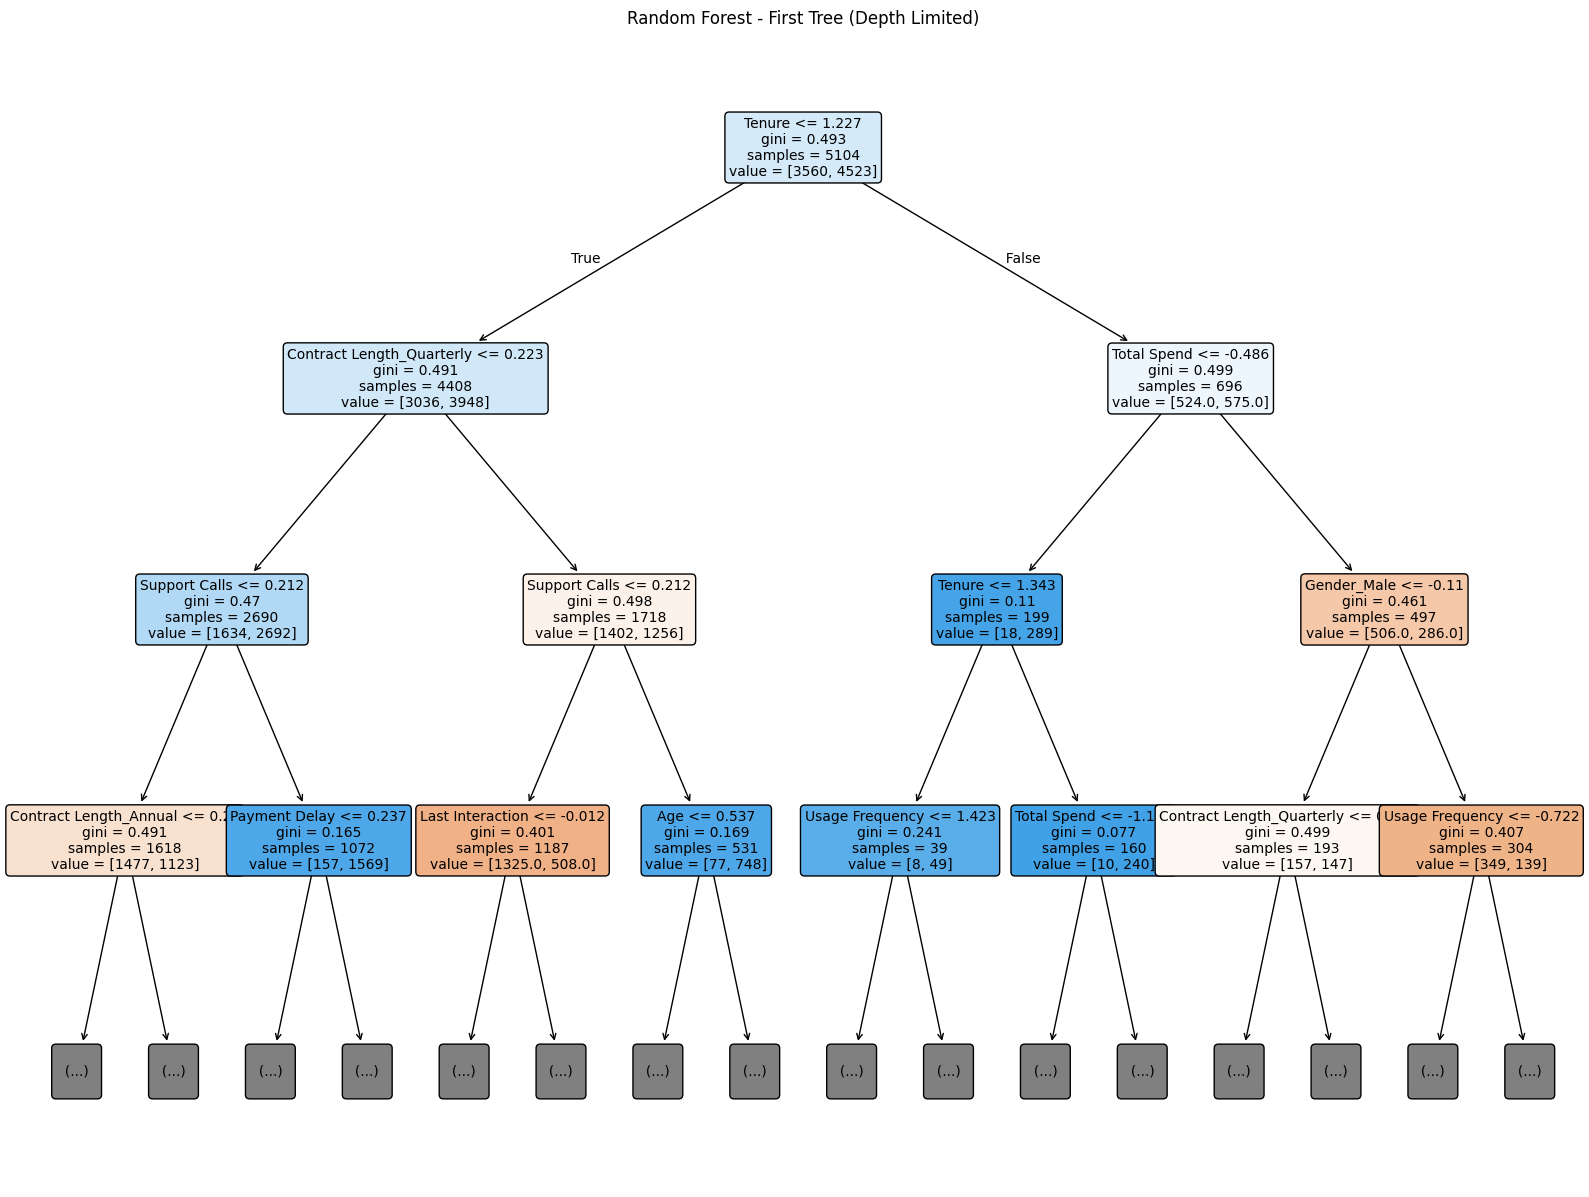

In [ ]:
from sklearn.tree import plot_tree

estimator = best_model.estimators_[0]  # First tree in the forest
plt.figure(figsize=(20, 15))
plot_tree(estimator,
          feature_names=X.columns,
          filled=True,
          max_depth=3,         # <--- Key change
          fontsize=10,
          rounded=True)
plt.title("Random Forest - First Tree (Depth Limited)")
plt.show()


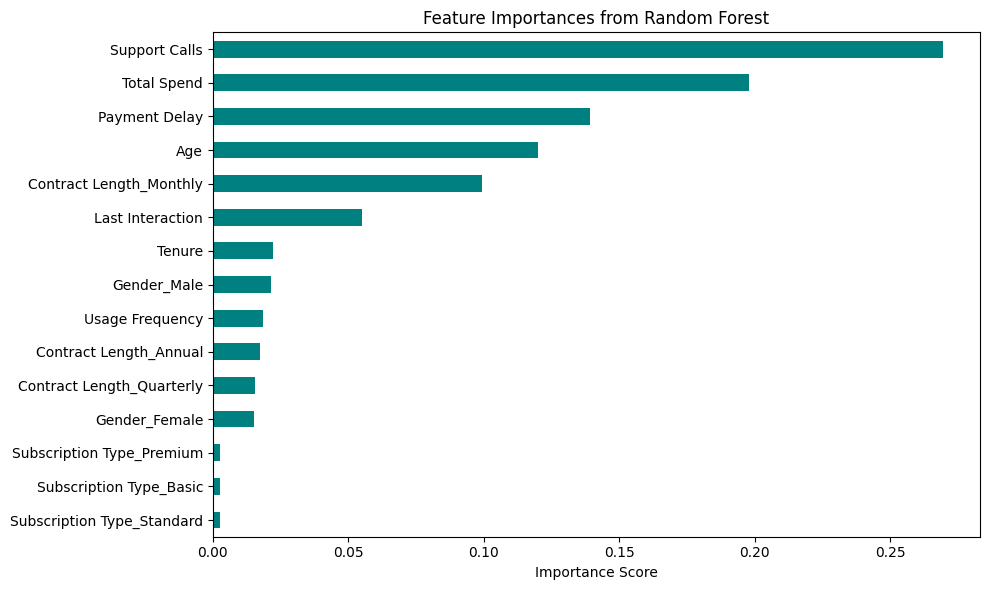

In [ ]:
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='teal')
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[38487  6456]
 [  900 55198]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.86      0.91     44943
         1.0       0.90      0.98      0.94     56098

    accuracy                           0.93    101041
   macro avg       0.94      0.92      0.93    101041
weighted avg       0.93      0.93      0.93    101041



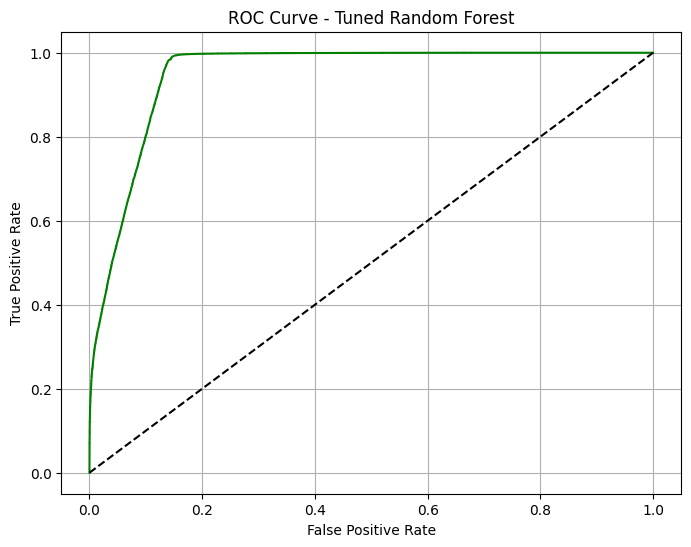

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.grid(True)

plt.savefig("roc_curve_rf_tuned.png", dpi=300)
plt.show()

In [ ]:
def explain_decision(sample_index, model, X, tree_id=0):
    """
    Explains the decision path for a single sample through a specific tree in the RandomForest.

    Args:
        sample_index (int): Index of the row/sample in X to explain.
        model (RandomForestClassifier): Trained RandomForest model.
        X (DataFrame): Input feature DataFrame.
        tree_id (int): Index of the tree in the forest to use (default = 0).
    """
    from sklearn.tree import _tree

    tree = model.estimators_[tree_id]
    sample = X.iloc[[sample_index]]

    node_indicator = tree.decision_path(sample)
    leaf_id = tree.apply(sample)

    feature = tree.tree_.feature
    threshold = tree.tree_.threshold

    print(f"\n📌 Decision Path for sample index {sample_index} in Tree #{tree_id}:\n")

    for node_id in node_indicator.indices:
        if leaf_id[0] == node_id:
            print(f"➡️ Reached leaf node {node_id}.")
            continue

        feat_index = feature[node_id]
        feat_name = X.columns[feat_index]
        threshold_val = threshold[node_id]
        sample_val = sample.iloc[0, feat_index]

        operator = "<=" if sample_val <= threshold_val else ">"
        print(f"🔹 Node {node_id}: ({feat_name} = {sample_val:.3f}) {operator} {threshold_val:.3f}")

In [ ]:
# Explain how sample 0 was classified by tree 0
explain_decision(sample_index=0, model=best_model, X=X, tree_id=0)


📌 Decision Path for sample index 0 in Tree #0:

🔹 Node 0: (Tenure = 39.000) > 1.227
🔹 Node 476: (Total Spend = 932.000) > -0.486
🔹 Node 514: (Gender_Male = 0.000) > -0.110
🔹 Node 580: (Usage Frequency = 14.000) > -0.722
🔹 Node 602: (Usage Frequency = 14.000) > 1.017
🔹 Node 628: (Total Spend = 932.000) > -0.364
🔹 Node 630: (Support Calls = 5.000) > -0.106
🔹 Node 638: (Last Interaction = 17.000) > 1.614
➡️ Reached leaf node 644.


In [ ]:
tree = best_model.estimators_[0]  # Tree 0
tree_struct = tree.tree_

node_id = 508

n_samples = tree_struct.n_node_samples[node_id]
value = tree_struct.value[node_id]  # [[n_class0, n_class1]]
gini = tree_struct.impurity[node_id]
prediction = value.argmax()

print(f"📍 Node {node_id}:")
print(f"- Samples: {n_samples}")
print(f"- Class distribution: {value}")
print(f"- Gini Impurity: {gini:.4f}")
print(f"- Predicted Class: {prediction}")

📍 Node 508:
- Samples: 3
- Class distribution: [[0.8 0.2]]
- Gini Impurity: 0.3200
- Predicted Class: 0


In [ ]:
explain_decision(sample_index=1, model=best_model, X=X, tree_id=8)


📌 Decision Path for sample index 1 in Tree #8:

🔹 Node 0: (Support Calls = 10.000) > 0.212
🔹 Node 328: (Last Interaction = 6.000) > 1.731
🔹 Node 566: (Payment Delay = 8.000) > -1.538
➡️ Reached leaf node 568.


In [ ]:
tree = best_model.estimators_[8]  # Tree 8
tree_struct = tree.tree_

node_id = 527

n_samples = tree_struct.n_node_samples[node_id]
value = tree_struct.value[node_id]  # [[n_class0, n_class1]]
gini = tree_struct.impurity[node_id]
prediction = value.argmax()

print(f"📍 Node {node_id}:")
print(f"- Samples: {n_samples}")
print(f"- Class distribution: {value}")
print(f"- Gini Impurity: {gini:.4f}")
print(f"- Predicted Class: {prediction}")

📍 Node 527:
- Samples: 2
- Class distribution: [[0.6 0.4]]
- Gini Impurity: 0.4800
- Predicted Class: 0


# Deployment

In [ ]:
import joblib
joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.6 MB/s eta 0:00:00


In [ ]:
import gradio as gr
from PIL import Image

mode_gender = df['Gender'].mode()[0]
mode_subscription_type = df['Subscription Type'].mode()[0]
mode_contract_length = df['Contract Length'].mode()[0]

In [ ]:
best_model = joblib.load("best_model.pkl")
roc_img = Image.open("roc_curve_rf_tuned.png")

In [ ]:
def churn_prediction(age, gender, tenure, usage_frequency, support_calls,
                     payment_delay, last_interaction, total_spend,
                     subscription_type, contract_length):
    try:

        input_data = {
            "Age": age,
            "Gender_Male": 1 if gender == "Male" else 0,
            "Gender_Female": 1 if gender == "Female" else 0,
            "Usage Frequency": usage_frequency,
            "Support Calls": support_calls,
            "Contract Length_Monthly": 1 if contract_length == "Monthly" else 0,
            "Contract Length_Quarterly": 1 if contract_length == "Quarterly" else 0,
            "Contract Length_Annual": 1 if contract_length == "Annual" else 0,
            "Payment Delay": payment_delay,
            "Last Interaction": last_interaction,
            "Total Spend": total_spend,
            "Tenure": tenure,
            "Subscription Type_Basic": 1 if subscription_type == "Basic" else 0,
            "Subscription Type_Premium": 1 if subscription_type == "Premium" else 0,
            "Subscription Type_Standard": 1 if subscription_type == "Standard" else 0,
        }

        input_df = pd.DataFrame([input_data])

        # Predict churn and probability
        prediction = best_model.predict(input_df)
        prediction_proba = best_model.predict_proba(input_df)[:, 1]

        churn_result = "Yes" if prediction[0] == 1 else "No"
        churn_probability = f"{prediction_proba[0]:.2f}"

        return churn_result, churn_probability, roc_img

    except Exception as e:
        return f"Error: {str(e)}", "N/A", None

In [ ]:
inputs = [
    gr.Slider(18, 100, value=40, label="Age"),
    gr.Dropdown(["Female", "Male"], value="Male", label="Gender"),
    gr.Slider(1, 60, value=31, label="Tenure (months)"),
    gr.Slider(1, 30, value=16, label="Usage Frequency"),
    gr.Slider(0, 10, value=4, label="Support Calls"),
    gr.Slider(0, 30, value=13, label="Payment Delay"),
    gr.Slider(1, 30, value=15, label="Last Interaction (days ago)"),
    gr.Slider(100, 1000, value=620, label="Total Spend"),
    gr.Dropdown(["Premium", "Standard", "Basic"], value="Standard", label="Subscription Type"),
    gr.Dropdown(["Monthly", "Quarterly", "Annual"], value="Annual", label="Contract Length")
]

outputs = [
    gr.Textbox(label="Churn Prediction"),
    gr.Textbox(label="Churn Probability"),
    gr.Image(label="ROC Curve")
]

In [ ]:
# trial function execution
churn_prediction(
    age=30,
    gender="Female",
    tenure=12,
    usage_frequency=10,
    support_calls=3,
    payment_delay=5,
    last_interaction=7,
    total_spend=500,
    subscription_type="Standard",
    contract_length="Monthly"
)

('Yes',
 '0.91',
 <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=2400x1800>)

In [2]:
# gr.Interface(fn=churn_prediction, inputs=inputs, outputs=outputs, title="Customer Churn Prediction").launch(share=True, debug = True)